# Labo d’Images Quantiques : Le Défi du FRQI

Bienvenue ! Aujourd’hui, nous explorons une question fondamentale : **comment encoder une image dans un ordinateur quantique ?**

L’informatique quantique vise à accélérer certains calculs afin de surmonter des limites auxquelles les ordinateurs classiques font face aujourd’hui dans plusieurs domaines.

Si nous voulons un jour appliquer ces idées au traitement d’images, ou à la vision par ordinateur quantique, nous devons d’abord répondre à une question préalable essentielle : **comment encoder une image sous forme d’état quantique ?**

Dans ce défi, vous découvrirez la technique FRQI, qui propose une réponse à cette question.

### Déroulement du défi

1. **Tutoriel** : Vous découvrirez l’encodage FRQI et apprendrez à construire un circuit quantique représentant une image noir et blanc.

2. **Le Défi des Images en Niveaux de Gris** : Vous apprendrez à gérer une image en niveaux de gris en encodant l’intensité des pixels avec la méthode FRQI.

   * **Problème 1** : Encoder une image en niveaux de gris dans un état quantique.

3. **Transformation d’Images** : Une fois l’image chargée dans un ordinateur quantique, vous devrez appliquer des transformations simples.

   * **Problème 2** : Négatif de l’image

   * **Problème 3** : Effet miroir horizontal


---

# 1. Tutoriel FRQI

## Une idée très naïve et intuitive : « un qubit par pixel »
L’approche la plus intuitive serait : **1 pixel ↔ 1 qubit** (encodage par pixel).
Pour une image de taille $W \times H$, cela demanderait **$N = W \times H$ qubits**.
  - Exemple : une image $32 \times 32$ → $N=1024$ pixels → 1024 qubits.

Mais cela pose un **problème** : en pratique, **les qubits sont une ressource rare**, bien plus rare que la mémoire classique. Donc cet encodage devient rapidement impossible, même pour de petites images. Il ignore également le fait qu’un qubit peut contenir plus d’information qu’un bit classique.

Nous cherchons donc une représentation utilisant peu de qubits, tout en pouvant adresser un grand nombre de pixels, et en exploitant potentiellement les spécificités des états quantiques.  
C’est là qu’intervient le **FRQI (Flexible Representation of Quantum Images)**.

## La représentation FRQI : le « où » + le « quoi »

L’idée du FRQI est plutôt simple : au lieu d’assigner **un qubit par pixel**, ce qui devient rapidement problématique lorsque la résolution augmente, on sépare :

- ***Le « où »*** : *quel pixel est ciblé ?* (son **adresse**)

- ***Le « quoi »*** : *quelle intensité/couleur a ce pixel ?* (sa **valeur**)

#### Petite question
Si vous disposez de $k$ qubits, combien d’adresses différentes pouvez-vous représenter ?

> Réponse naturelle : $2^k$ (de `000…0` à `111…1`).  
> De plus, avec des portes de Hadamard, nous pouvons placer ces $k$ qubits en **superposition** et obtenir “toutes les adresses à la fois”.

C’est exactement l’idée : **les qubits de position servent à adresser les pixels**.

### ***Le « où »*** : adresser les pixels avec des qubits de position
Si une image contient $N$ pixels au total, alors nous devons pouvoir représenter $N$ adresses différentes. Avec $k$ qubits, nous pouvons adresser jusqu’à $2^k$ positions. On choisit donc $k$ tel que $2^k \ge N$, ce qui donne :
  
$$
k = \lceil \log_2(N) \rceil
$$

Si $2^k > N$, certaines adresses ne correspondront à aucun pixel : on les ignore simplement.

Ensuite, pour avoir **toutes les adresses possibles en même temps**, on applique simplement une porte de Hadamard sur **chaque** qubit de position. Nous partons de l’état initial du registre de "position" : $|0\rangle^{\otimes k}$ (adresse `000…0`).\\
 Après $H^{\otimes k}$ (la porte Hadamard appliquée $k$ fois), on obtient une **superposition uniforme** de toutes les chaînes binaires de longueur $k$ (de `000…0` à `111…1`). Mathématiquement, cela s'écrit ainsi :

$$
|0\rangle^{\otimes k} \xrightarrow{H^{\otimes k}}
\frac{1}{\sqrt{2^k}} \sum_{i=0}^{2^k - 1} |i\rangle
$$

Ici, $|i\rangle$ représente l’adresse binaire du pixel $i$, avec $i$ allant de $0$ à $2^k - 1$.

Le registre de "position" **couvre toutes les adresses possibles** en superposition, chaque adresse ayant la même amplitude.  
C’est exactement le mécanisme derrière l’idée d'*adresser tous les pixels à la fois*.

### ***Le « quoi »*** : le qubit de couleur
On ajoute **1 qubit** pour encoder la valeur de couleur associée à chaque adresse :
- image noir/blanc : valeur binaire $0$ pour blanc, $1$ pour noir.

- image en niveaux de gris : une intensité allant de $0$ à $1$.

### Formule FRQI générale
Pour une image avec $N$ pixels :
$$
\text{Nombre total de qubits FRQI} = \lceil \log_2(N) \rceil + 1
$$

**Cas particulier**
Si l’image est carrée avec une taille de $2^n \times 2^n$, alors $N = 2^{2n}$, donc $\log_2(N)=2n$ et :
$$
\text{Qubits totaux} = 2n + 1
$$

#### Exemple concret : image $32 \times 32$
Une image $32 \times 32$ contient $N = 1024$ pixels.
- Qubits de position : $\log_2(1024) = 10$ (car $2^{10} = 1024$)
- Qubit de couleur : $1$
- Total : **11 qubits**

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import utils_images as img_utils
import utils_quantum as q_utils
import importlib
importlib.reload(img_utils)

<module 'utils_images' from '/Users/chei2402/Documents/github/algolab-quantique/hackathons/Sherhack/2026 Winter/side_quests/quantum_image_lab/utils_images.py'>

## Exemple d'encodage simple d'une image binaire 4x4

Nous voulons construire un circuit FRQI simple qui encode une image noir et blanc, le mesurer et reconstruire l'image à partir des résultats.

### Définition du problème
- Nous avons une image 4×4 qui contient **16 pixels**. Nous devons donc adresser **16 positions**.

- Comme $2^4 = 16$, nous devons utiliser **4 qubits de position** pour l'adresse ($q_0, q_1, q_2, q_3$).

- Nous ajoutons **1 qubit de couleur** ($q_4$) pour encoder la valeur du pixel (**0 = blanc**, **1 = noir**).

### Encodage FRQI
#### Superposition des adresses de pixels
   - Appliquez une porte $H$ à chacun des qubits de position ($q_0 \dots q_3$).
   - Le registre de position devient une superposition uniforme de **toutes les adresses** (`0000` à `1111`).

#### Encoder les pixels noirs en utilisant le contrôle par adresse
   - Pour chaque **adresse** correspondant à un pixel noir, nous voulons que le qubit de couleur ($q_4$) bascule à 1.
   - Pour cela, nous utilisons une porte X à contrôles multiples ou **`MCX`** :
     - **Contrôles** : les qubits de position ($q_0 \dots q_3$)
     - **Cible** : le qubit de couleur ($q_4$)

**Astuce : Contrôle sur des 0**
Une porte `MCX` "standard" s'active lorsque **tous les contrôles sont égaux à 1**. Si l'adresse ciblée contient des **0** (ex. : `0000`), nous créons un petit "masque" :
1. Nous appliquons des portes $X$ aux qubits de position qui devraient être à 0 pour transformer temporairement ces 0 en 1.

2. Nous appliquons la porte `MCX` qui va maintenant se déclencher.

3. Nous ré-appliquons les mêmes portes $X$ pour **annuler** le masque et ramener le registre à son état normal.

> Idée clé à retenir : les portes $X$ servent uniquement à "convertir" un contrôle-sur-0 en un contrôle-sur-1, après quoi nous annulons proprement l'opération.

---
### Important : Comment lire les résultats ?

 Il y a souvent une confusion entre le diagramme du circuit et le résultat écrit. Clarifions cela tout de suite :

 1.  **Dans le circuit** : Qiskit place généralement $q_0$ en haut.

 2.  **Dans la chaîne de bits du résultat** : Qiskit inverse l'ordre d'affichage pour qu'il corresponde à la lecture "naturelle" d'un nombre (c'est-à-dire le bit de poids fort à gauche).

 **La Règle de Lecture Visuelle**
 Pour une chaîne de résultat comme **`"10011"`** :
 - **Tout à GAUCHE** ($q_4$) : Le bit de poids fort est le *qubit de couleur*.
 - **Tout à DROITE** ($q_0$) : C'est le bit de poids faible.
 - On lit donc cela ainsi : **"C p3 p2 p1 p0"**.

 *Note technique :* C'est parce que Qiskit utilise le stockage "Little Endian" en mémoire ($q_0$ est le premier), mais affiche la chaîne inversée ($q_n \dots q_0$) pour faciliter la lecture humaine.

---

In [2]:
import math
import numpy as np
from qiskit import QuantumCircuit

def _apply_x_mask(qc: QuantumCircuit, address_bitstring: str, position_qubits: list[int]):
    """
    Apply an X-mask to emulate controls-on-0 for an address.

    Why:
    - A standard MCX triggers only when all control qubits are |1>.
    - If an address bit is 0, we temporarily flip the corresponding qubit with X
      so that MCX can trigger, then we undo the mask later.

    Args:
    - qc: QuantumCircuit to modify.
    - address_bitstring: "natural" binary string (MSB on the left), e.g. "0101".
    - position_qubits: ordered list of position-qubit indices (q0 = LSB).
      Note: if position_qubits == [0, 1, 2, ...], then position_qubits[i] == i.
    """
    # Reverse so index 0 aligns with q0 (LSB)
    for bit_idx, bit in enumerate(reversed(address_bitstring)):
        if bit == "0":
            qc.x(position_qubits[bit_idx])

In [3]:
def encode_frqi_simple(binary_image: np.ndarray) -> tuple[QuantumCircuit, int]:
    """
    Pedagogical FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    flat = np.array(binary_image).astype(int).flatten() # flatten to 1D array row-major order: row0, row1, ...
    n_pixels = len(flat)
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels)) # number of position qubits
    n_total = n_pos + 1                    # +1 color qubit
    pos_qubits = list(range(n_pos))        # q0..q(k-1)
    color_qubit = n_pos                    # qk

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")
    
    # Create circuit
    qc = QuantumCircuit(n_total)

    # Step 1) Superposition over addresses
    for q in pos_qubits:
        qc.h(q)
    # can also be written as: qc.h(pos_qubits)


    # Step 2) Encode black pixels with MCX

    for i, pixel_val in enumerate(flat):
        if int(pixel_val) != 1:         # only encode black pixels (value 1)
            continue

        address_bitstring = format(i, f"0{n_pos}b")  # MSB..LSB (natural)

        _apply_x_mask(qc, address_bitstring, pos_qubits) # apply X-mask for controls-on-0
        qc.mcx(pos_qubits, color_qubit)                  # Multi-controlled X: flip color qubit when ALL position qubits are |1⟩
        _apply_x_mask(qc, address_bitstring, pos_qubits)  # undo (X is its own inverse)

        qc.barrier() # barrier for visual clarity

        # Note: MCX can apply the sandwiching X gates automatically with the ctrl_state option,

    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")
    
    return qc, n_pos # return circuit and number of position qubits

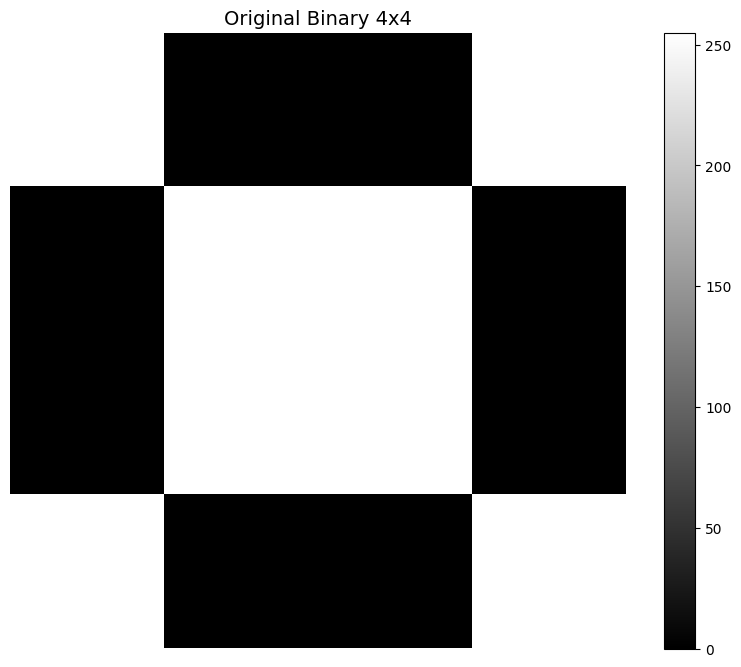

In [6]:
# Create a simple 4x4 binary image (Cross pattern)
frqi_test_image = np.array([
    [1, 0, 0, 1],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [1, 0, 0, 1]
])

img_utils.display_image(frqi_test_image * 255, "Original Binary 4x4")

 FRQI circuit created!
   Depth: 23, Size: 44 gates


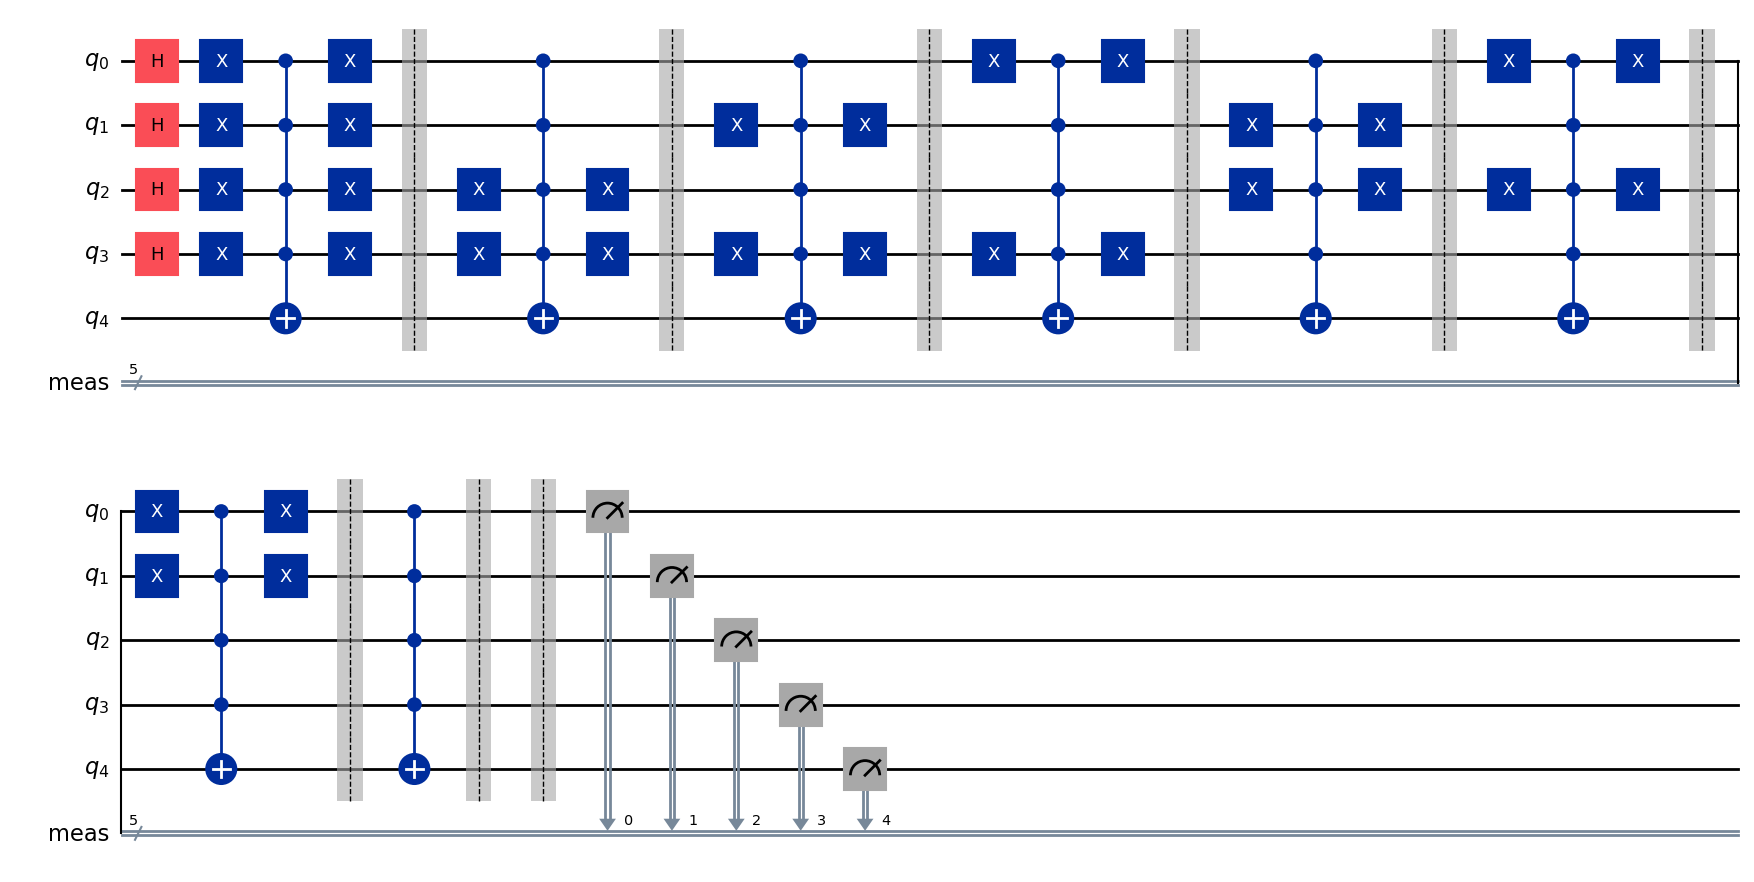

In [7]:
# Build FRQI circuit
frqi_circuit, n_pos = encode_frqi_simple(frqi_test_image)

# very important: add measurement to the circuit
frqi_circuit.measure_all()

frqi_circuit.draw(output="mpl")

### Mesurer le circuit : reconstruction de l'image

Nous mesurons l'état quantique plusieurs fois pour reconstruire l'image.

#### Comprendre les résultats de la mesure
Nous avons $k$ qubits de position + 1 qubit de couleur, la mesure produit donc une chaîne de bits de cette longueur. Cette chaîne représente **UN SEUL état de base**, et donc **L'ÉTAT D'UN SEUL pixel** avec son adresse et sa couleur.

***Le FRQI ne nous donne pas toute l'image d'un coup !***
Puisque l'état est dans une **superposition** de toutes les adresses de pixels avec leur couleur associée, la mesure va aléatoirement "s'effondrer" sur l'une d'entre elles.
Cela signifie que vous devez prendre **DE NOMBREUSES mesures** (c'est-à-dire des *shots*) afin de reconstruire l'image entière.
L'expérience doit être répétée suffisamment de fois pour être statistiquement certain que chaque adresse a été échantillonnée plusieurs fois.

**Heuristique recommandée :**
- Nombre minimum de *shots* $ > 50 \times \text{Nombre de pixels}$.
- Nombre de *shots* pour une meilleure qualité $ > 200 \times \text{Nombre de pixels}$.

#### Reconstruction de l'image : la méthode du "Ratio"
Puisque les résultats arrivent légèrement dans le désordre, nous **accumulons des statistiques par adresse** :
1. `total_counts[i]` : Combien de fois on est tombé sur l'adresse $i$.
2. `ones_counts[i]` : Parmi ces fois-là, combien de fois l'encodage de la couleur valait 1 (noir).

Nous calculons ensuite le ratio pour chaque pixel :
$$ \text{Ratio}(i) = \frac{\text{ones\_counts}[i]}{\text{total\_counts}[i]} $$

Si le ratio > 0.5, c'est un pixel noir !

> **Pourquoi s'en préoccuper si c'est si lent ?**
> Reconstruire une image pixel par pixel avec des millions de mesures est inefficace ; un ordinateur classique est plus rapide. Le véritable but du traitement d'image quantique est de **manipuler** l'image en superposition (par ex., appliquer des filtres, des transformations, etc.) **avant** la mesure. Mais ici, dans ce tutoriel, nous reconstruisons l'image pour **prouver** que notre encodage fonctionne !

In [8]:
def reconstruct_from_frqi(counts, n_position_qubits, image_shape):
    """
    Reconstruct image from FRQI measurement counts using the 'Ratio' method.
    Args:
    - counts: dict from measurement outcomes to counts.
    - n_position_qubits: number of position qubits used in FRQI.
    - image_shape: tuple (height, width) of the original image.
    
    Returns:
    - reconstructed_image: 2D numpy array of the reconstructed image.
    """
    
    n_pixels = image_shape[0] * image_shape[1] # Total number of pixels
    
    # 1. Accumulate statistics per pixel (Address)
    total_counts = np.zeros(n_pixels, dtype=int)
    ones_counts = np.zeros(n_pixels, dtype=int)
    
    print("Reconstructing image from measurements...\n")
    
    # For each measurement outcome (e.g., '10101')
    for outcome, count in counts.items():
        # Remove spaces if any
        outcome = outcome.replace(" ", "")
        
        # --- VISUAL MAPPING (Left -> High Index) ---
        # The string typically looks like: "C P3 P2 P1 P0"
        # Leftmost character is the Color Qubit
        color_char = outcome[0] 
        
        # The rest is the Position (binary string)
        position_string = outcome[1:]
        
        # Convert "1101" -> 13 (Standard binary: Left is MSB)
        position_idx = int(position_string, 2)
        
        # Only process valid pixel positions
        if position_idx < n_pixels:
            # Accumulate counts for this address
            total_counts[position_idx] += count
            
            # If color bit is 1, count it as a "black" measurement
            if int(color_char) == 1:
                ones_counts[position_idx] += count
    
    # 2. Compute Pixel Values based on Ratio
    reconstructed = np.zeros(n_pixels, dtype=int)
    
    for i in range(n_pixels):
        if total_counts[i] > 0:
            # Calculate proportion of 1s (Intensity)
            ratio = ones_counts[i] / total_counts[i]
            
            # For Binary: Threshold at 50%
            if ratio > 0.5:
                reconstructed[i] = 1
    
    # Reshape to original image dimensions
    reconstructed_image = reconstructed.reshape(image_shape) # from 1D to 2D, row-major order
    
    return reconstructed_image


Reconstructing image from measurements...


Reconstructed image:
[[1 0 0 1]
 [0 1 1 0]
 [0 1 1 0]
 [1 0 0 1]]


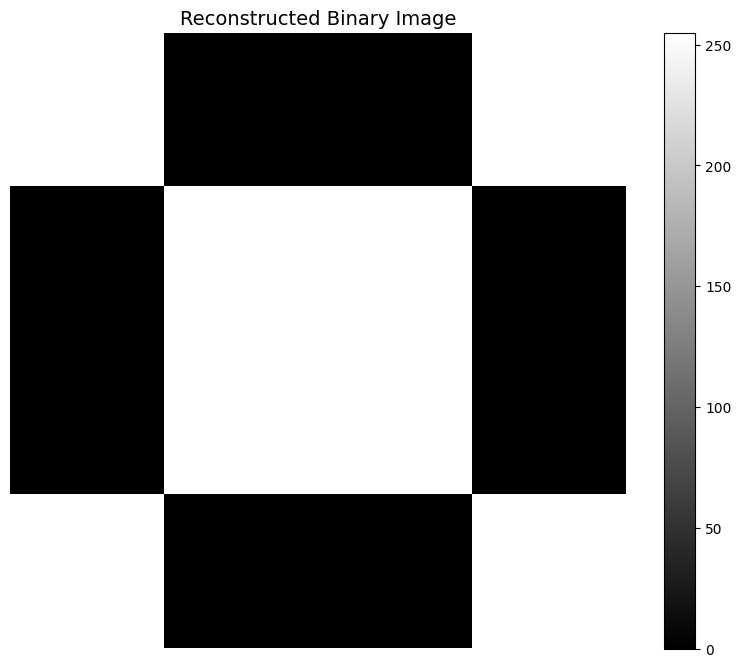

In [9]:

# Note: Since FRQI is probabilistic (superposition), we need enough shots 
# to ensure every pixel address is measured at least a few times.
# Heuristic: shots > 50 * n_pixels
num_shots = (2**n_pos) * 50 # n_pos : number of qubits for adresses => n_pixels = 2**n_pos
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_from_frqi(counts, n_pos, frqi_test_image.shape)

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

img_utils.display_image(frqi_reconstructed * 255, "Reconstructed Binary Image")

---

# 2. Le défi des images en niveaux de gris

Contrairement aux images en **noir et blanc** où nous n'avons besoin d'encoder qu'une valeur binaire pour la couleur (0 pour blanc, 1 pour noir), les images en **niveaux de gris** nécessitent que le qubit de couleur encode une valeur flottante (`float`) (une valeur de gris allant de 0 à 1).
Par conséquent, la seule différence dans le processus par rapport au cas noir et blanc réside dans l'encodage du qubit de couleur. Nous remplaçons le comportement "tout ou rien" par une *rotation* du qubit de couleur.

L'outil pour cela est la porte **`RY`** (ou porte de rotation autour de l'axe Y).

### La porte `RY`
Dans les manuels et dans Qiskit, l'action de la porte `RY` est définie comme :

$$
RY(\phi)=
\begin{pmatrix}
\cos(\phi/2) & -\sin(\phi/2) \\
\sin(\phi/2) & \cos(\phi/2)
\end{pmatrix}.
$$

Le détail important est que **la matrice utilise des demi-angles** ($\phi/2$).  
Donc, si on applique `RY(φ)` sur l'état $|0\rangle$, on obtient :
$$
RY(\phi)\,|0\rangle = \cos(\phi/2)\,|0\rangle + \sin(\phi/2)\,|1\rangle.
$$

Cependant, nous voulons travailler avec un angle plus "propre" $\theta$ :
$$
|\psi\rangle = \cos(\theta)\,|0\rangle + \sin(\theta)\,|1\rangle.
$$

Pour que cela corresponde, il faut que $\phi/2 = \theta$, donc **$\phi = 2\theta$** :
$$
RY(2\theta)\,|0\rangle = \cos(\theta)\,|0\rangle + \sin(\theta)\,|1\rangle.
$$

C'est pour cela que nous utilisons le fameux `mcry(2*theta, ...)` dans Qiskit.

### Le piège classique : "Je vais juste prendre $\theta = I$"

Nous voulons que l'intensité du pixel $I$, normalisée entre 0 et 1, corresponde à la **probabilité** de mesurer 1 sur le qubit de couleur :
$$
P(|1\rangle)=I
$$

À ce stade, beaucoup de gens se disent : "OK, je vais juste définir $\theta = I$".  
**Cela semble naturel, mais c'est incorrect** car en mécanique quantique, la probabilité de mesurer un état quantique n'est pas égale à son amplitude mais au **carré de son amplitude**.

Rappelez-vous que si nous avons un état quantique général
$$
|\psi\rangle = \cos(\theta)\,|0\rangle + \sin(\theta)\,|1\rangle,
$$
la probabilité de mesurer $|1\rangle$ est
$$
P(|1\rangle)=|\sin(\theta)|^2=\sin^2(\theta)
$$

Donc si nous voulons $P(|1\rangle)=I$, nous devons résoudre :
$$\sin^2(\theta)=I$$
$$\sin(\theta)=\sqrt{I}$$
$$\theta=\arcsin(\sqrt{I})$$

Et comme Qiskit attend l'angle $\phi$ pour `RY(φ)` (avec le demi-angle), nous appliquerons finalement **`2*theta`** dans `mcry`.

### Reconstruction de l'image
Vous n'avez besoin de rien réinventer : la **méthode du Ratio** fonctionne toujours. Pour les images en niveaux de gris, il est courant que les interfaces graphiques s'attendent à ce que l'intensité d'un pixel soit un entier compris entre 0 (blanc) et 255 (noir). Par conséquent, il nous suffit d'estimer l'intensité normalisée $I$ en mesurant notre circuit plusieurs fois, et de la remettre à l'échelle :
$$ I_{\text{reconstruit}} = \text{ratio} \times 255$$

---

### **Problème 1 : Encodage et reconstruction d'une image en niveaux de gris 4×4**

 Testing FRQI with Ratio-based Reconstruction on 4×4 grayscale image

Original 4×4 grayscale image


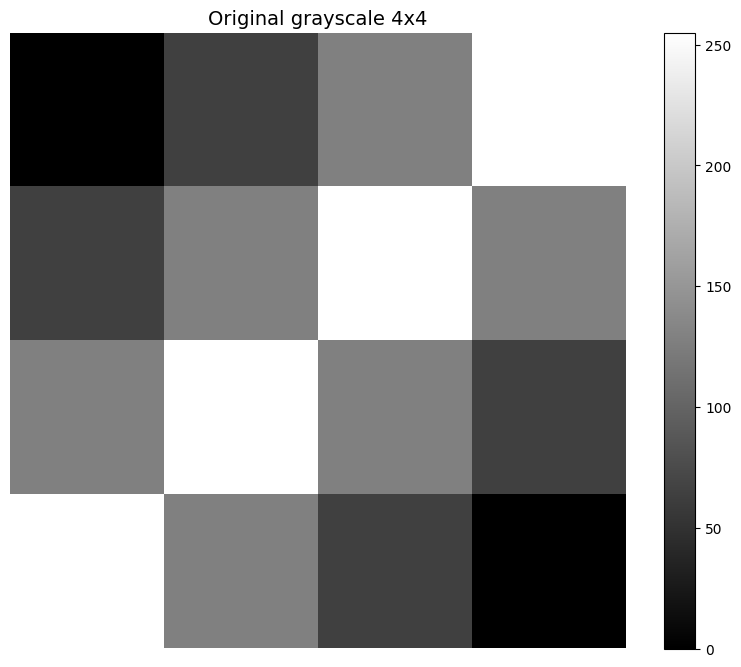

In [10]:
# Test with simple 4×4 grayscale image first
print(" Testing FRQI with Ratio-based Reconstruction on 4×4 grayscale image\n")

# Create a 4x4 grayscale image
grayscale_4x4 = np.array([
    [0, 64, 128, 255],
    [64, 128, 255, 128],
    [128, 255, 128, 64],
    [255, 128, 64, 0]
], dtype=np.uint8)

print("Original 4×4 grayscale image")
img_utils.display_image(grayscale_4x4, "Original grayscale 4x4")

In [ ]:
# TODO : FRQI encoder for grayscale image
def encode_frqi_grayscale(grayscale_image: np.ndarray) -> tuple[QuantumCircuit, int]:
     flat = np.array(grayscale_image).astype(int).flatten()    #Flatten to 1D array
     n_pixels = len(flat)
     if n_pixels == 0:
          raise ValueError("Empty image.")
     
     n_pos = math.ceil(math.log2(n_pixels))     #Number of positions possible with encoding
     n_total = n_pos + 1                        #Number of total qubit including color
     pos_qubits = list(range(n_pos))            #List with all possible positions
     color_qubit = n_pos                        #Index of the qubit dedicated to color

     #Message if there are more spaces added.
     if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")

     #Create quantum circuit
     qc = QuantumCircuit(n_total)
   
     #Puts all qubits in superposition
     for q in pos_qubits:
        qc.h(q)

     #Goes through all pixels in the image
     for i, pixel_val in enumerate(flat):
        if int(pixel_val) == 0:         # only encode black pixels (value 1)
            continue
        
        #Calculate theta. Theta = ArcSin(SQRT(pixel value normalized))
        theta = math.asin(math.sqrt(pixel_val/255))*2

        address_bitstring = format(i, f"0{n_pos}b")  # MSB..LSB (natural)

        _apply_x_mask(qc, address_bitstring, pos_qubits) # apply X-mask for controls-on-0
        qc.mcrx(theta, pos_qubits, color_qubit)           # Multi-controlled X: flip color qubit when ALL position qubits are |1⟩
        _apply_x_mask(qc, address_bitstring, pos_qubits)  # undo (X is its own inverse)

        qc.barrier() # barrier for visual clarity

     return qc, n_pos


In [17]:
# TODO : FRQI decoder for grayscale image

def reconstruct_grayscale_from_frqi(counts: dict, n_position_qubits: int, image_shape: tuple[int, int]) -> np.ndarray:
   n_pixels = image_shape[0] * image_shape[1]

   total_counts = np.zeros(n_pixels, dtype=int)
   ones_counts = np.zeros(n_pixels, dtype=int)

   for outcome, count in counts.items():
        # Remove spaces if any
        outcome = outcome.replace(" ", "")
        
        # --- VISUAL MAPPING (Left -> High Index) ---
        # The string typically looks like: "C P3 P2 P1 P0"
        # Leftmost character is the Color Qubit
        color_char = outcome[0] 
        
        # The rest is the Position (binary string)
        position_string = outcome[1:]
        
        # Convert "1101" -> 13 (Standard binary: Left is MSB)
        position_idx = int(position_string, 2)
        
        # Only process valid pixel positions
        if position_idx < n_pixels:
            # Accumulate counts for this address
            total_counts[position_idx] += count
            
            # If color bit is 1, count it as a "black" measurement
            if int(color_char) == 1:
                ones_counts[position_idx] += count

   reconstructed = np.zeros(n_pixels, dtype=int)
   for i in range(n_pixels):
        if total_counts[i] > 0:
            ratio = ones_counts[i] / total_counts[i]

            reconstructed[i] = int(255*ratio)

   reconstructed_image = reconstructed.reshape(image_shape)

   return reconstructed_image

In [27]:
# Build FRQI circuit
frqi_circuit, n_pos = encode_frqi_grayscale(grayscale_4x4)

# very important: add measurement to the circuit
frqi_circuit.measure_all()

#frqi_circuit.draw(output="mpl")


Reconstructed image:
[[  0  59 126 255]
 [ 58 128 255 130]
 [127 255 126  56]
 [255 138  62   0]]


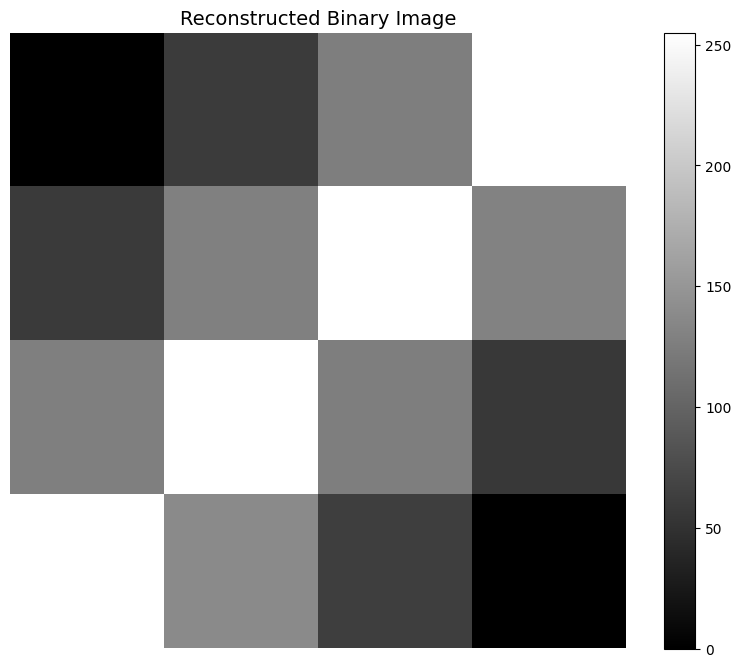

In [49]:
# Note: Since FRQI is probabilistic (superposition), we need enough shots 
# to ensure every pixel address is measured at least a few times.
# Heuristic: shots > 50 * n_pixels
num_shots = 200 * (2**n_pos) # 200 shots per pixel address
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_grayscale_from_frqi(counts, n_pos, frqi_test_image.shape)

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

img_utils.display_image(frqi_reconstructed, "Reconstructed Binary Image")

### (Optionnel) Évaluer la qualité de la reconstruction"
        
Pour vérifier si l’encodage/décodage fonctionne bien, on peut comparer l’image reconstruite à l’image originale en calculant l’**erreur absolue** par pixel (et la **MAE**, *Mean Absolute Error*), puis en visualisant : **originale / reconstruite / carte d’erreur**.



 Results:
Original range: [0, 255]
Retrieved range: [0, 255]

 Error analysis:
   Mean absolute error: 2.38


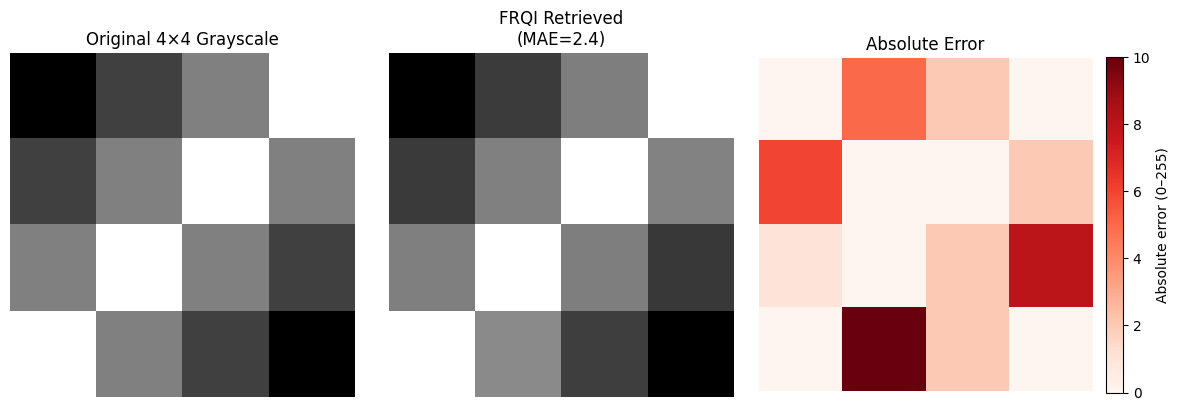

In [50]:
mae, error = img_utils.compare_grayscale_reconstruction(
    grayscale_4x4,
    frqi_reconstructed,   # or retrieved_image, etc.
    show=True,
    verbose=True,
    title_original="Original 4×4 Grayscale",
    title_reconstructed="FRQI Retrieved",
)

# 3. Transformations simples sur l'image quantique

Maintenant que nous savons comment charger et décoder une image dans un ordinateur quantique en utilisant l'encodage FRQI, nous allons apprendre à **modifier une image quantique en appliquant des portes quantiques** à son circuit.

Pour avancer, nous allons d'abord **nous rappeler comment une image 2D est adressée par des qubits**, puis **comment une porte quantique agit sur tout l'état en superposition**.

## De l'indexation 2D à l'indexation 1D

Une image est une matrice `M` de taille `(height, width)`. Pour repérer un pixel `M[y][x]`, nous utilisons deux indices :

- **`y`** : l'**index de ligne**
- **`x`** : l'**index de colonne**

Pour passer de 2D à 1D (ou inversement), NumPy utilise par défaut l'ordre **row-major (C-order)** :
- on parcourt d'abord la **ligne y=0** et tous ses éléments dans les colonnes `x = 0,1,2,…`
- puis la **ligne y=1** et tous ses éléments dans les colonnes `x = 0,1,2,…`, etc.

Donc :
- **`x` change vite** (LSB)
- **`y` change lentement** (MSB)

### Exemple : Adresses binaires 4×4
Chaque case affiche `yy_xx` :
- `yy` = ligne `y` (MSB)
- `xx` = colonne `x` (LSB)

| y \ x | 0 | 1 | 2 | 3 |
|---:|:---:|:---:|:---:|:---:|
| 0 | 00_00 | 00_01 | 00_10 | 00_11 |
| 1 | 01_00 | 01_01 | 01_10 | 01_11 |
| 2 | 10_00 | 10_01 | 10_10 | 10_11 |
| 3 | 11_00 | 11_01 | 11_10 | 11_11 |

**À retenir :** Les qubits de droite (LSB) contrôlent l'**index de colonne** `x`, et les qubits de gauche (MSB) contrôlent l'**index de ligne** `y`.

## Encodage FRQI 2D : Explication de l'expression mathématique

Vous verrez souvent cette formule dans les articles de recherche pour décrire une image quantique $|I\rangle$ :

$$ |I\rangle = \frac{1}{\sqrt{N}} \sum_{y} \sum_{x} |y\rangle |x\rangle \otimes |f(y,x)\rangle $$

Déchiffrons-la terme par terme :

*   **La Somme $\sum_{y} \sum_{x}$** : Cela signifie que notre état quantique est une **superposition** de TOUS les pixels de l'image en même temps.

*   **La Position $|y\rangle |x\rangle$** : Cela représente l'adresse binaire (ou l'étiquette) du pixel. Par exemple, le pixel à la ligne 0, colonne 1 est représenté par l'état $|0\rangle|1\rangle$.

*   **Le Produit Tensoriel $\otimes$** : C'est le lien qui "colle" la position à sa couleur. On peut le lire comme "associé à".

*   **L'Information de Couleur $|f(y,x)\rangle$** : C'est ce qui contient l'intensité du pixel en $(y,x)$.

    *   Dans notre cas (FRQI), c'est un état d'un seul qubit ($|0\rangle$, $|1\rangle$, ou une superposition) qui encode le niveau de gris.
    
    *   L'idée est simplement : pour chaque adresse visible dans la somme, le qubit de couleur prend la valeur correspondante.

## L'effet *massif* des portes sur les adresses en superposition

Une seule porte quantique appliquée sur un qubit d'adresse modifie **toutes les adresses**. En fait, elle modifie *toute l'image*, et pas seulement une adresse à la fois.

Considérons un système quantique avec 3 qubits d'adresse ($q_2q_1q_0$). Cela signifie que nous avons $2^3 = 8$ adresses possibles, qui composent l'état de superposition général de toutes les adresses :
$$
|\psi\rangle = \{|000\rangle, |001\rangle, \dots, |111\rangle\}
$$

Quand on applique une porte **sur un qubit d'adresse**, on n'agit pas *sur un seul pixel*.

Disons que nous appliquons `X` sur le qubit de colonne de poids fort $q_2$

$$
X_2\,|q_2 q_1 q_0\rangle = |(q_2 \oplus 1)\,q_1 q_0\rangle
$$

La porte **affecte chaque terme de la superposition en même temps** sur ce qubit d'adresse particulier.
Cela signifie : **toutes les adresses commençant par 0 deviennent des adresses commençant par 1**, et inversement.

Soit :
- L'adresse `000` devient `100`
- L'adresse `001` devient `101`
- etc.

$$
|\psi\rangle = \{|100\rangle, |101\rangle, \dots, |011\rangle\}
$$

Visuellement, cela revient à échanger deux gros blocs de l'image en une seule opération.

---

### **Problème 2 : Négatif photo**
Vous devez obtenir un effet *photo négative* en inversant les intensités de l'image en niveaux de gris du problème 1.  
*Indice* : dans FRQI, le qubit de couleur porte l'information d'intensité ; agir sur lui peut inverser l'interprétation "clair/sombre" selon la convention de décodage utilisée.

In [51]:
# TODO ...
# Indice : Ajoutez UNE SEULE porte pour inverser les couleurs
#          la porte agit sur le qubit de couleur (le dernier qubit, d'index n_pos)
def invert_color(qc: QuantumCircuit, color_qubit: int):
    qc.x(color_qubit)

---
### **Problème 3 : Retourner l'image**
Vous devez retourner l'image en niveaux de gris 8x8 générée par la cellule suivante.
Indice :
* Échangez les blocs (gauche ↔ droite) pour comprendre le rôle du **bit de poids fort de `x`**.
* Effectuez le miroir horizontal en inversant tous les bits de `x`.

Image originale (8x8) :


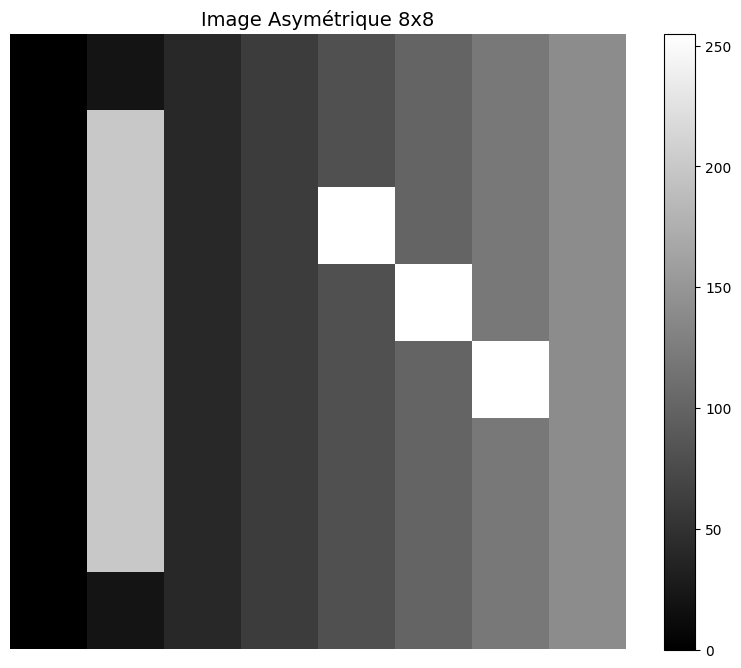

In [52]:

# Création d'une image 8x8 spéciale pour tester le miroir
image_8x8 = np.zeros((8, 8), dtype=np.uint8)

# --- Moitié GAUCHE (Colonnes 0, 1, 2, 3) ---
# On dessine une barre verticale lumineuse à la colonne 1
image_8x8[1:7, 1] = 200

# --- Moitié DROITE (Colonnes 4, 5, 6, 7) ---
# On dessine une diagonale (triangle)
for i in range(3):
    image_8x8[2+i, 4+i] = 255

# + Un léger dégradé de fond (0..140) pour que chaque colonne soit unique
# (Cela aide à voir si une colonne a été inversée ou juste déplacée)
for y in range(8):
    for x in range(8):
        image_8x8[y, x] = max(image_8x8[y, x], x * 20)

print("Image originale (8x8) :")
img_utils.display_image(image_8x8, "Image Asymétrique 8x8")


Simulation en cours (cela peut prendre quelques secondes avec 64 pixels)...


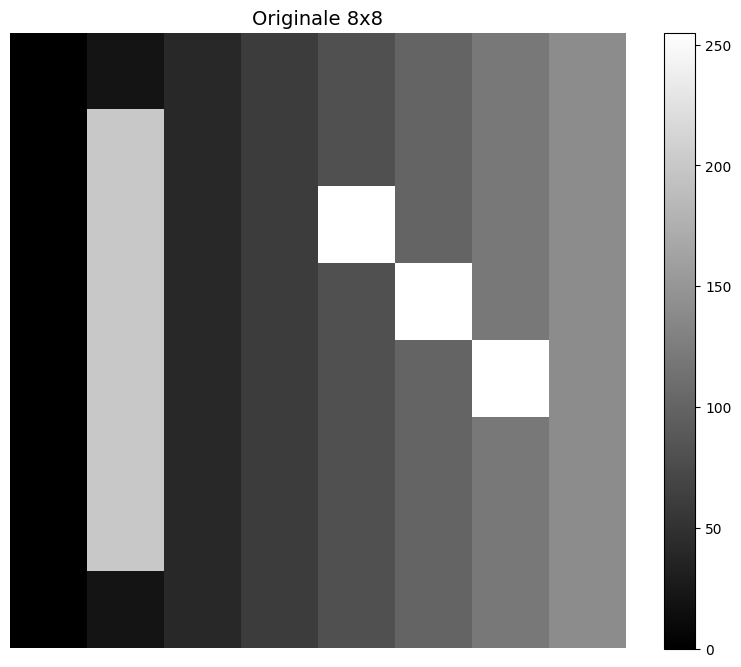

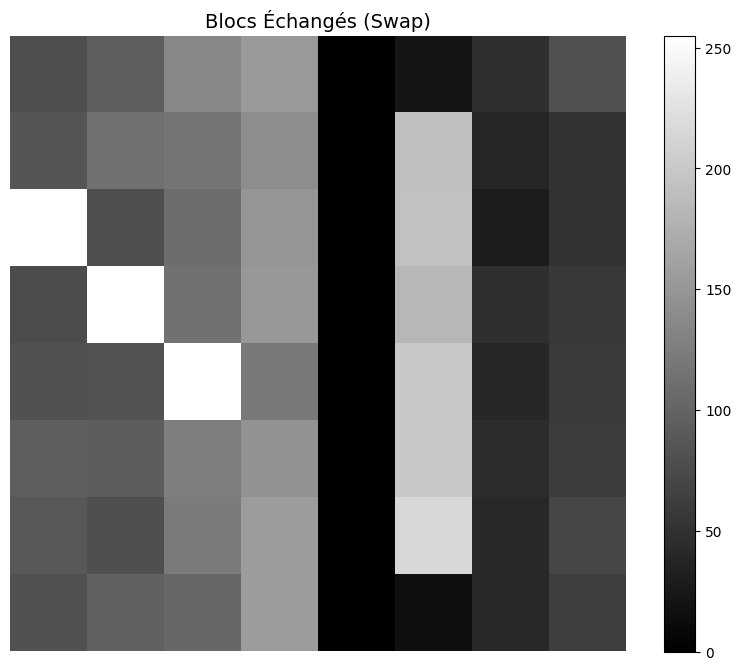

In [55]:
# 3.1) Swap des blocs (colonnes) (gauche [0,1,2,3] ↔ droite [4,5,6,7])
# TODO ...
frqi_circuit_swap, n_pos = encode_frqi_grayscale(image_8x8)

frqi_circuit_swap.x(2)

frqi_circuit_swap.measure_all()

print("Simulation en cours (cela peut prendre quelques secondes avec 64 pixels)...")
num_shots = 200 * (2**n_pos)
counts_swap = q_utils.run_simulation(frqi_circuit_swap, shots=num_shots)

frqi_swap_reconstructed = reconstruct_grayscale_from_frqi(counts_swap, n_pos, image_8x8.shape)

img_utils.display_image(image_8x8, "Originale 8x8")
img_utils.display_image(frqi_swap_reconstructed, "Blocs Échangés (Swap)")

Simulation en cours (cela peut prendre quelques secondes avec 64 pixels)...


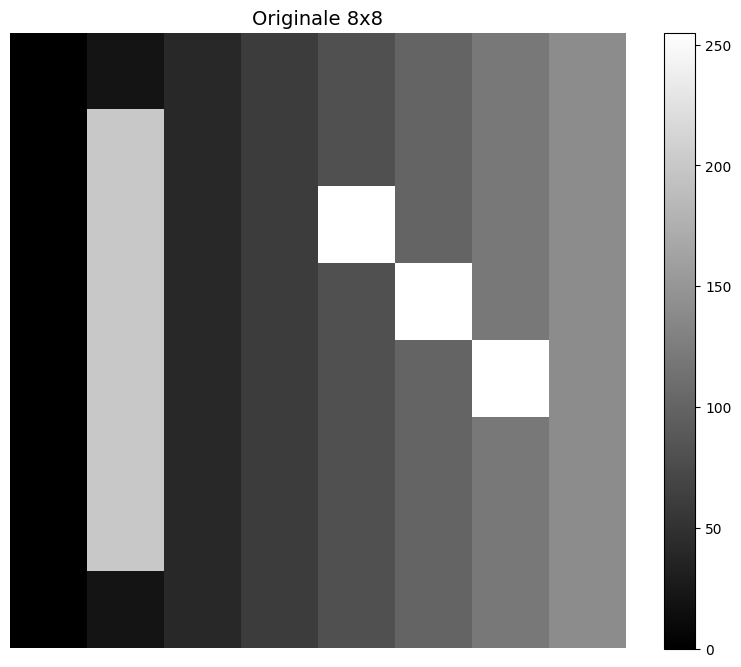

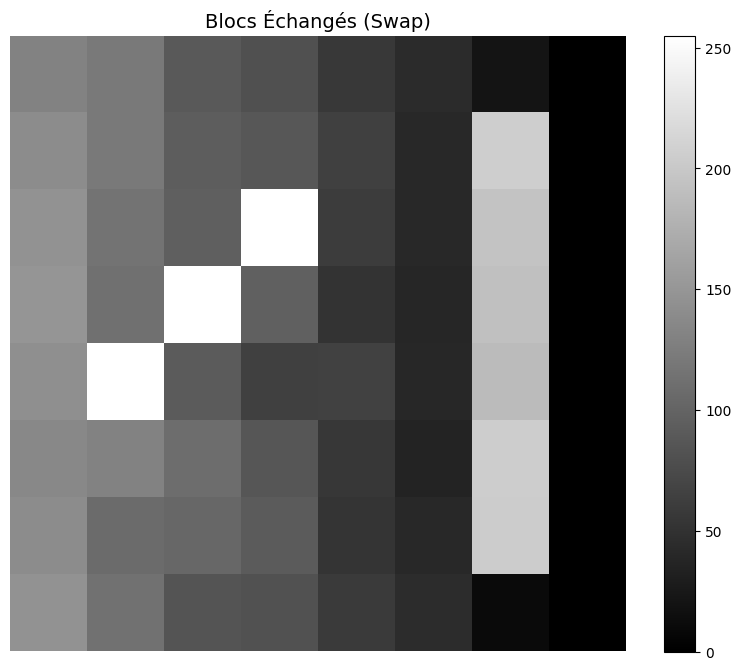

In [68]:
# --- 2) Miroir Complet (Flip Horizontal) ---
# TODO ...
frqi_circuit_swap, n_pos = encode_frqi_grayscale(image_8x8)

frqi_circuit_swap.x(2)
frqi_circuit_swap.x(1)
frqi_circuit_swap.x(0)

frqi_circuit_swap.measure_all()

print("Simulation en cours (cela peut prendre quelques secondes avec 64 pixels)...")
num_shots = 200 * (2**n_pos)
counts_swap = q_utils.run_simulation(frqi_circuit_swap, shots=num_shots)

frqi_swap_reconstructed = reconstruct_grayscale_from_frqi(counts_swap, n_pos, image_8x8.shape)

img_utils.display_image(image_8x8, "Originale 8x8")
img_utils.display_image(frqi_swap_reconstructed, "Blocs Échangés (Swap)")